<a href="https://colab.research.google.com/github/fox-n/ML_course_homeworks/blob/main/Copy_of_LSTM_%D0%B4%D0%BB%D1%8F_%D0%BF%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D1%83%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F_%D1%87%D0%B0%D1%81%D0%BE%D0%B2%D0%B8%D1%85_%D1%80%D1%8F%D0%B4%D1%96%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Давайте подивимося, як LSTM можна використовувати для побудови нейронної мережі прогнозування часових.

Будемо працювати з задачею прогнозування кількості пасажирів міжнародних авіаліній. З цим набором даних ми вже працювали в лекції "Time Series Analysis" і ви зможете порівняти результати :)

Задача полягає в тому, щоб за заданими роком і місяцем передбачити кількість пасажирів міжнародних авіаліній в одиницях виміру 1,000. Дані охоплюють період з січня 1949 року по грудень 1960 року, тобто 12 років, зі 144 спостереженнями.

Це регресійна задача. Тобто, знаючи кількість пасажирів (в тисячах) за останні місяці, можна передбачити, якою буде кількість пасажирів у наступному місяці. Набір даних має лише одну характеристику: "Кількість пасажирів" - `Passengers`.

Далі вже наведений код для читання даних, але нам їх ще треба буде трошки обробити.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader,TensorDataset



In [2]:
# Завантаження даних
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.set_index('Month', inplace=True)
display(df.head())

,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


**Завдання 1.** Створіть змінну типу `numpy.ndarray`, яка містить значення кількості пасажирів в форматі `float32`. Такий формат даних нам треба для тренування нейромережі.

In [3]:
passengers_array = df['Passengers'].to_numpy(dtype=np.float32)
passengers_array


array([112., 118., 132., 129., 121., 135., 148., 148., 136., 119., 104.,
       118., 115., 126., 141., 135., 125., 149., 170., 170., 158., 133.,
       114., 140., 145., 150., 178., 163., 172., 178., 199., 199., 184.,
       162., 146., 166., 171., 180., 193., 181., 183., 218., 230., 242.,
       209., 191., 172., 194., 196., 196., 236., 235., 229., 243., 264.,
       272., 237., 211., 180., 201., 204., 188., 235., 227., 234., 264.,
       302., 293., 259., 229., 203., 229., 242., 233., 267., 269., 270.,
       315., 364., 347., 312., 274., 237., 278., 284., 277., 317., 313.,
       318., 374., 413., 405., 355., 306., 271., 306., 315., 301., 356.,
       348., 355., 422., 465., 467., 404., 347., 305., 336., 340., 318.,
       362., 348., 363., 435., 491., 505., 404., 359., 310., 337., 360.,
       342., 406., 396., 420., 472., 548., 559., 463., 407., 362., 405.,
       417., 391., 419., 461., 472., 535., 622., 606., 508., 461., 390.,
       432.], dtype=float32)

Очікуваний результат:
```array([112., 118., 132., 129., 121.], dtype=float32)```

**Завдання 2**. Розбийте дані на тренувальні і валідаційні у співвідношенні 67% йде у тренування, 33 - у валідацію. Памʼятаємо, що ми працюємо з tim series, відповідно, навчаємось на давніших, валідуємось - на новіших.

In [4]:
split_idx = int(len(passengers_array) * 0.67)

In [5]:
train, test = np.split(passengers_array, [split_idx])

**Завдання 3**.

Реалізуйте функцію `create_dataset`, яка перетворить одномірний часовий ряд (набір даних) у формат, придатний для тренування нейромережі.

Функція повинна приймати два аргументи:
- `dataset` — numpy-масив часового ряду,
- `lookback` — кількість попередніх кроків, які використовуватимуться для передбачення.

Функція повинна повернути два **тензори** PyTorch:
- `X` — набір ознак (вікно попередніх значень),
- `y` — цільові значення (наступні після вікна кроки).

Дані ми будемо подавати моделі в наступному форматі:
`
tensor([[112.],
        [118.],
        [132.],
        [129.],
        [121.]])
`
Відповідно першою розмірністю буде йти розмір вхідного батча, а другою - розмір вхіднизх даних і в нас це 1, бо лише одне значення на вході щоразу.

Після виконання завдання запустіть код нижче. Ми будемо передбачати на основі кількості пасажирів в попередній день кількість пасажирів в наступний, тому `lookback == 1`.

In [6]:
def create_dataset(dataset, lookback):
  X = []
  y = []
  for i in range (len(dataset) - lookback):
   feature = dataset[i:i+lookback]
   target = dataset[i+1:i+lookback+1]
   X.append(feature)
   y.append(target)

  X = np.array(X)
  y = np.array(y)

  return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


In [7]:
lookback = 1
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])


Очікуваний результат:
```
torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])
```

**Завдання 4**.

Зверніть увагу на розмірності в попередньому завданні. Ми
З допомогою модуля `torch.nn` опишіть клас `AirModel`, який є нейронною мережею для прогнозування кількості пасажирів за допомогою LSTM.

1. **Конструктор класу** повинен приймати параметри `hidden_size`, `num_layers` та ініціювати шари:
   - LSTM-шар з наступними параметрами:
     - `input_size` — кожна точка часового ряду є окремим входом,,
     - `hidden_size` — заданий в конструкторі класу мережі,
     - `num_layers=1` — кількість шарів LSTM, задана в конструкторі мережі,
     - `batch_first=True` — визначає, що першим виміром є розмір батчу.
   - Лінійний шар (`nn.Linear`) для перетворення виходу LSTM на прогноз однієї точки.

2. **Метод forward** повинен виконувати наступні дії:
   - Передати вхідний тензор через LSTM-шар і отримати виходи (ігноруючи приховані стани).
   - Пропустити вихід LSTM через лінійний шар для отримання остаточного прогнозу.

Створіть об'єкт класу `AirModel` зі значеннями параметрів `hidden_size=50`, `num_layers=1` і протестуйте роботу моделі на вхідному тензорі `tensor([[112.]])`. На цьому етапі ми маємо переконатись, що модель здатна генерувати передбачення з рандомно ініційованими вагами.

In [8]:
class AirModel(nn.Module):
  def __init__(self, hidden_size, num_layers):
        super(AirModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.air = nn.LSTM(1, hidden_size, num_layers, batch_first=True)
        self.lin = nn.Linear(hidden_size, 1)

  def forward(self, x):
    out, _ = self.air(x)
    out = self.lin(out)
    return out


In [9]:
air_model = AirModel(hidden_size=50, num_layers=1)
print(air_model)

AirModel(
  (air): LSTM(1, 50, batch_first=True)
  (lin): Linear(in_features=50, out_features=1, bias=True)
)


In [10]:
air_model(torch.tensor([[112.]]))

tensor([[0.3314]], grad_fn=<AddmmBackward0>)

**Завдання 5**.

Створіть об'єкт DataLoader для завантаження даних, використовуючи тренувальні вибірки `X_train` та `y_train`. Ваш DataLoader повинен виконувати наступні вимоги:

1. Використовувати клас `TensorDataset`, щоб об'єднати тензори ознак `X_train` і цільових значень `y_train`.
2. Дані повинні завантажуватися невеликими батчами розміром 8 за допомогою параметра `batch_size`.
3. Використовувати параметр `shuffle=True`, щоб дані перемішувалися перед кожною епохою тренування.


In [11]:
train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

**Завдання 6**.

1. Реалізуйте навчання нейронної мережі `AirModel` для прогнозування часових рядів, використовуючи Adam-оптимізатор та функцію втрат MSE (середньоквадратичну похибку).
2. Створіть цикл тренування для 2000 епох, у якому на кожній епосі:
   - Виконуйте крок тренування моделі (прямий прохід, обчислення похибки, зворотний прохід і оновлення ваг).
   - Підраховуйте середню похибку на кожному батчі даних і зберігайте її у списку `losses`.
3. Раз на 100 епох проводьте валідацію моделі:
   - Перевіряйте модель на тренувальних та тестових даних без оновлення ваг.
   - Обчислюйте корінь середньоквадратичної похибки (RMSE) для тренувальної та тестової вибірок і виводьте результати на екран.
   
**Примітка:**
- Використовуйте вже створений `DataLoader` для отримання батчів даних.
- Валідацію виконуйте в режимі `eval()`, вимикаючи обчислення градієнтів з `torch.no_grad()`.

**Приклад виходу:**
```
Epoch 0: train RMSE 12.3456, test RMSE 15.6789
Epoch 100: train RMSE 9.8765, test RMSE 12.3456
...
```

In [12]:
def train_model(model, train_loader, criterion, optimizer):
  model.train()
  epoch_losses = []

  for X_batch, y_batch in train_loader:
    optimizer.zero_grad()
    y_pred = model(X_batch)
    loss = criterion(y_pred, y_batch)
    loss.backward()
    optimizer.step()
    epoch_losses.append(loss.item())
  return np.mean(epoch_losses)

def evaluate (model, X, y, criterion):
  model.eval()
  with torch.no_grad():
        y_pred = model(X)
        rmse = torch.sqrt(criterion(y_pred, y))
  return rmse.item()



In [14]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(air_model.parameters(), lr=0.01)
n_epochs = 2000

#losses = train_model(air_model, train_loader, criterion, optimizer)

In [15]:
losses = []
for epoch in range(n_epochs):
    epoch_loss = train_model(air_model, train_loader, criterion, optimizer)
    losses.append(epoch_loss)

    if epoch % 100 == 0:
        train_rmse = evaluate(air_model, X_train, y_train, criterion)
        test_rmse = evaluate(air_model, X_test, y_test, criterion)
        print(f"Epoch {epoch}: train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}")

Epoch 0: train RMSE 221.9795, test RMSE 418.3183
Epoch 100: train RMSE 53.9491, test RMSE 207.4299
Epoch 200: train RMSE 39.8044, test RMSE 165.8711
Epoch 300: train RMSE 36.8266, test RMSE 158.0964
Epoch 400: train RMSE 34.1405, test RMSE 143.7694
Epoch 500: train RMSE 31.4043, test RMSE 139.1754
Epoch 600: train RMSE 30.5963, test RMSE 131.8311
Epoch 700: train RMSE 30.2279, test RMSE 133.5175
Epoch 800: train RMSE 30.1296, test RMSE 134.3497
Epoch 900: train RMSE 32.0113, test RMSE 142.1475
Epoch 1000: train RMSE 30.4757, test RMSE 135.0463
Epoch 1100: train RMSE 30.6149, test RMSE 139.6990
Epoch 1200: train RMSE 30.4265, test RMSE 136.0644
Epoch 1300: train RMSE 33.0615, test RMSE 137.7360
Epoch 1400: train RMSE 29.8968, test RMSE 128.0881
Epoch 1500: train RMSE 31.8307, test RMSE 130.5445
Epoch 1600: train RMSE 30.1068, test RMSE 126.8903
Epoch 1700: train RMSE 29.3679, test RMSE 129.7426
Epoch 1800: train RMSE 31.2062, test RMSE 136.3175
Epoch 1900: train RMSE 33.8715, test RMSE 

**Завдання 7.** Побудуйте графік лосів. Зробіть висновок з графіку, чи навчилась модель?

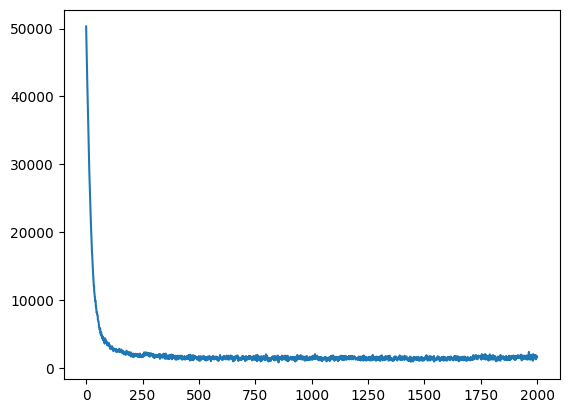

In [16]:
plt.plot(losses);

###Висновок
Видно, що loss спадає, тобто модель вчиться, проте протягом другої тисячі епох значення loss вже не сильно змінюється. Також помітна велика різниця в RMSE на вибірках train та test.

Модель навчилась, але не факт, що точно)

Доволі неочікувано, що середньоквадратичне відхилення тестового набору даних буде на порядок більшим за одиниці в нашому наборі даних. Середньоквадратичне відхилення 100 означає, що прогноз і фактичне значення будуть відрізнятися в середньому на 100 (тобто, 100 000 пасажирів у цьому наборі даних).



Щоб краще зрозуміти якість прогнозу, ви можете побудувати графік з кодом нижче (а ще нижче - описано, що відбувається в цьому коді, бо це теж корисно зрозуміти):

In [17]:
len(X_train)

95

/tmp/ipykernel_100594/2023805843.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  train_plot[lookback:train_size] = air_model(X_train)[:, -1]
/tmp/ipykernel_100594/2023805843.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  test_plot[train_size+lookback:len(passengers_array)] = air_model(X_test)[:, -1]


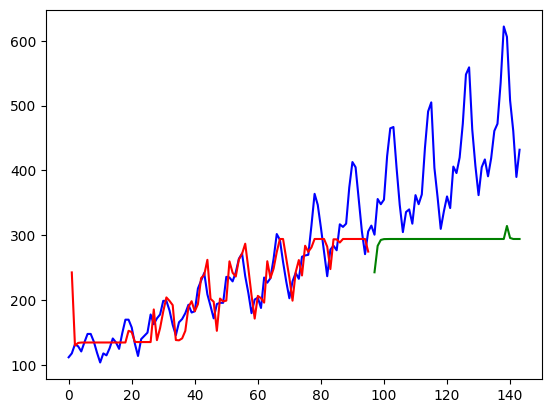

In [18]:
def plot_predicts():
  with torch.no_grad():
      # Зсув прогнозів для тренувальних даних
      train_size = len(train)
      train_plot = np.ones_like(passengers_array) * np.nan
      y_pred = air_model(X_train)
      y_pred = y_pred[:, -1]
      train_plot[lookback:train_size] = air_model(X_train)[:, -1]

      # Зсув прогнозів для тестових даних
      test_plot = np.ones_like(passengers_array) * np.nan
      test_plot[train_size+lookback:len(passengers_array)] = air_model(X_test)[:, -1]

  # Візуалізація результатів
  plt.plot(passengers_array, c='b')  # Реальні дані
  plt.plot(train_plot, c='r')  # Прогнози на тренувальних даних
  plt.plot(test_plot, c='g')   # Прогнози на тестових даних
  plt.show()

plot_predicts()

**Що відбувається в коді вище.** В цьому коді здійснюється процес прогнозування часових рядів за допомогою LSTM моделі, а також виведення графіку, який показує реальні значення, тренувальні та тестові прогнози. Ось що відбувається на кожному етапі:

1. **`torch.no_grad()`**: Цей контекстний менеджер вимикає обчислення градієнтів, що означає, що під час прогнозування не будуть зберігатися проміжні обчислення для зворотного проходу (backpropagation). Це підвищує ефективність під час прогнозування і зменшує використання пам'яті.

2. **Зсув прогнозів для тренувальних даних:**
   - Створюється масив `train_plot`, який має такий самий розмір, як і часовий ряд (`timeseries`), і заповнюється значеннями NaN (`np.nan`), щоб залишити місце для реальних значень.
   - Модель передбачає виходи для тренувальних даних `X_train`.
   - Використовується лише останнє передбачене значення для кожного входу LSTM (`y_pred[:, -1]`).
   - Прогнози зсуваються, починаючи з індексу `lookback` до кінця тренувальних даних (індекс `train_size`). Цей зсув потрібен, щоб зробити прогноз на основі попередніх даних і відобразити його на правильній частині графіку.

3. **Зсув прогнозів для тестових даних:**
   - Створюється масив `test_plot`, який також заповнюється NaN.
   - Прогнози для тестових даних додаються з індексу `train_size + lookback` до кінця реальних даних, щоб відобразити, де модель починає прогнозувати тестову вибірку.

4. **Побудова графіка:**
   - `plt.plot(timeseries, c='b')`: Виводить реальні значення часового ряду (синя лінія).
   - `plt.plot(train_plot, c='r')`: Виводить тренувальні прогнози (червона лінія).
   - `plt.plot(test_plot, c='g')`: Виводить тестові прогнози (зелена лінія).

**Чому це робиться:**
- Зсув прогнозів для тренувальних і тестових даних дозволяє візуально зрівняти, наскільки добре модель прогнозує як на тренувальній, так і на тестовій вибірках. Зазвичай, червона лінія (тренувальні прогнози) повинна точно відповідати синій лінії (реальні дані), а зелена лінія (тестові прогнози) дає змогу побачити, наскільки модель добре працює на нових даних, яких вона раніше не бачила.

###Висновок
На графіку також видно, що на тренувальних даних модель спрацювала добре, а при валідації втратила тренд.

**Завдання 8**. Навчіть модель з hidden_size=100 та порівняйте результати прогнозів з попередніми.

In [22]:
air_model_2 = AirModel(hidden_size=100, num_layers=1)
optimizer_2 = torch.optim.Adam(air_model_2.parameters(), lr=0.01)

In [25]:
losses_2 = []
for epoch in range(n_epochs):
    epoch_loss = train_model(air_model_2, train_loader, criterion, optimizer_2)
    losses_2.append(epoch_loss)

    if epoch % 100 == 0:
        train_rmse = evaluate(air_model_2, X_train, y_train, criterion)
        test_rmse = evaluate(air_model_2, X_test, y_test, criterion)
        print(f"Epoch {epoch}: train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}")

Epoch 0: train RMSE 218.5763, test RMSE 414.9339
Epoch 100: train RMSE 37.7961, test RMSE 164.3235
Epoch 200: train RMSE 32.1988, test RMSE 143.1185
Epoch 300: train RMSE 29.2514, test RMSE 129.5922
Epoch 400: train RMSE 30.7548, test RMSE 130.1282
Epoch 500: train RMSE 29.2823, test RMSE 130.0517
Epoch 600: train RMSE 28.9435, test RMSE 121.5595
Epoch 700: train RMSE 26.9149, test RMSE 116.8277
Epoch 800: train RMSE 31.2101, test RMSE 127.0246
Epoch 900: train RMSE 29.8782, test RMSE 131.4855
Epoch 1000: train RMSE 29.3633, test RMSE 129.1505
Epoch 1100: train RMSE 29.2733, test RMSE 125.0792
Epoch 1200: train RMSE 28.5215, test RMSE 123.4092
Epoch 1300: train RMSE 28.3755, test RMSE 123.4976
Epoch 1400: train RMSE 29.2608, test RMSE 126.3668
Epoch 1500: train RMSE 29.0864, test RMSE 122.2604
Epoch 1600: train RMSE 26.1646, test RMSE 119.8189
Epoch 1700: train RMSE 27.6267, test RMSE 117.0400
Epoch 1800: train RMSE 28.6076, test RMSE 119.8549
Epoch 1900: train RMSE 27.6618, test RMSE 

/tmp/ipykernel_100594/1982830368.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  train_plot[lookback:train_size] = air_model_2(X_train)[:, -1]
/tmp/ipykernel_100594/1982830368.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  test_plot[train_size+lookback:len(passengers_array)] = air_model_2(X_test)[:, -1]


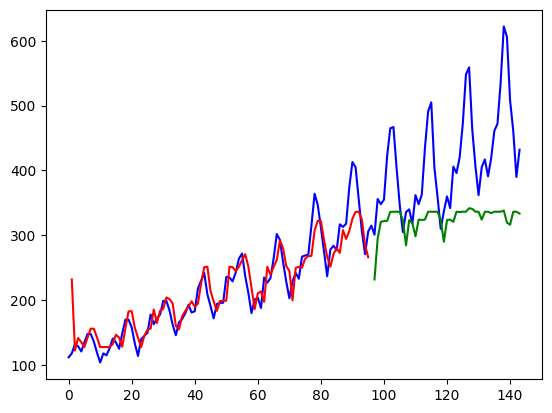

In [26]:
def plot_predicts():
  with torch.no_grad():
      # Зсув прогнозів для тренувальних даних
      train_size = len(train)
      train_plot = np.ones_like(passengers_array) * np.nan
      y_pred = air_model_2(X_train)
      y_pred = y_pred[:, -1]
      train_plot[lookback:train_size] = air_model_2(X_train)[:, -1]

      # Зсув прогнозів для тестових даних
      test_plot = np.ones_like(passengers_array) * np.nan
      test_plot[train_size+lookback:len(passengers_array)] = air_model_2(X_test)[:, -1]

  # Візуалізація результатів
  plt.plot(passengers_array, c='b')  # Реальні дані
  plt.plot(train_plot, c='r')  # Прогнози на тренувальних даних
  plt.plot(test_plot, c='g')   # Прогнози на тестових даних
  plt.show()

plot_predicts()

##Висновок
Використання hidden_size = 100 трохи поліпшило результати, проте помилка всеодно доволі велика.
Можливо варто було спробувати відскейлити вхідні дані для моделі.